In [1]:
from collections import defaultdict
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")

from lib.utils import constants
from lib.utils.seq_utils import get_mutation_position

In [2]:
# Load data
df = pd.read_csv("../data/cytotoxicity/dataset.csv")
wt_seq = constants.HINGE_28 + constants.TM_28 + constants.COSTIM_28
wt_val = df[df.id == "wild-type"].cytotoxic_activity.values
df_mut = df[df.id != "wild-type"]
df_mut["mutation_position"] = df_mut.sequence.apply(lambda x: get_mutation_position(x[:len(wt_seq)], wt_seq))

/tmp/ipykernel_284776/3373042382.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mut["mutation_position"] = df_mut.sequence.apply(lambda x: get_mutation_position(x[:len(wt_seq)], wt_seq))


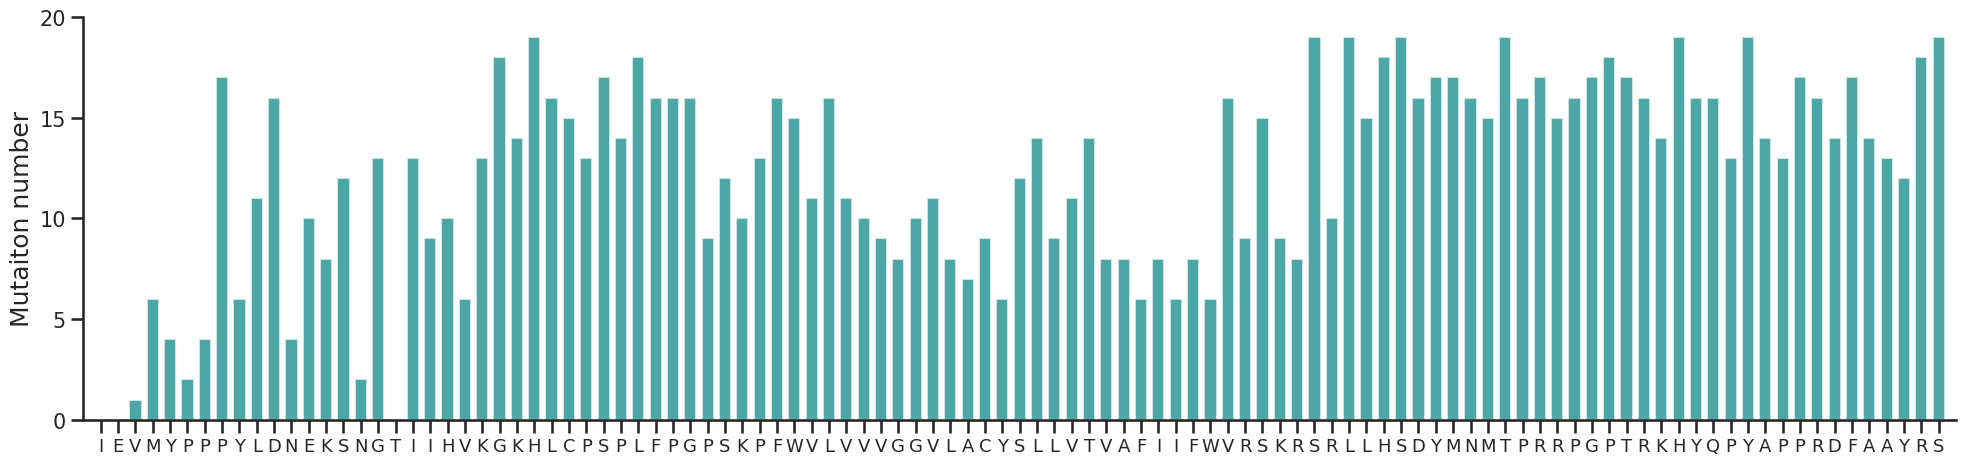

In [3]:
# Mutation number
mutations = set()
for val in df_mut.mutation_position:
    val = val.split(":")
    mutations = mutations | set(val)
mutation_posi = [int(mut[1:-1]) for mut in mutations]
p, c = np.unique(mutation_posi, return_counts=True)


# Plot
fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(x=p, height=c, color="teal", alpha=0.7, width=0.7)
ax.set_xlim(0-1, len(wt_seq))
ax.set_ylabel("Mutaiton number")
ax.set_xticks(range(len(wt_seq)), list(wt_seq), fontsize=13)
ax.set_yticks([0, 5, 10, 15, 20] ,[0, 5, 10, 15, 20], fontsize=15)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/mutaiton_number_at_each_position.svg")

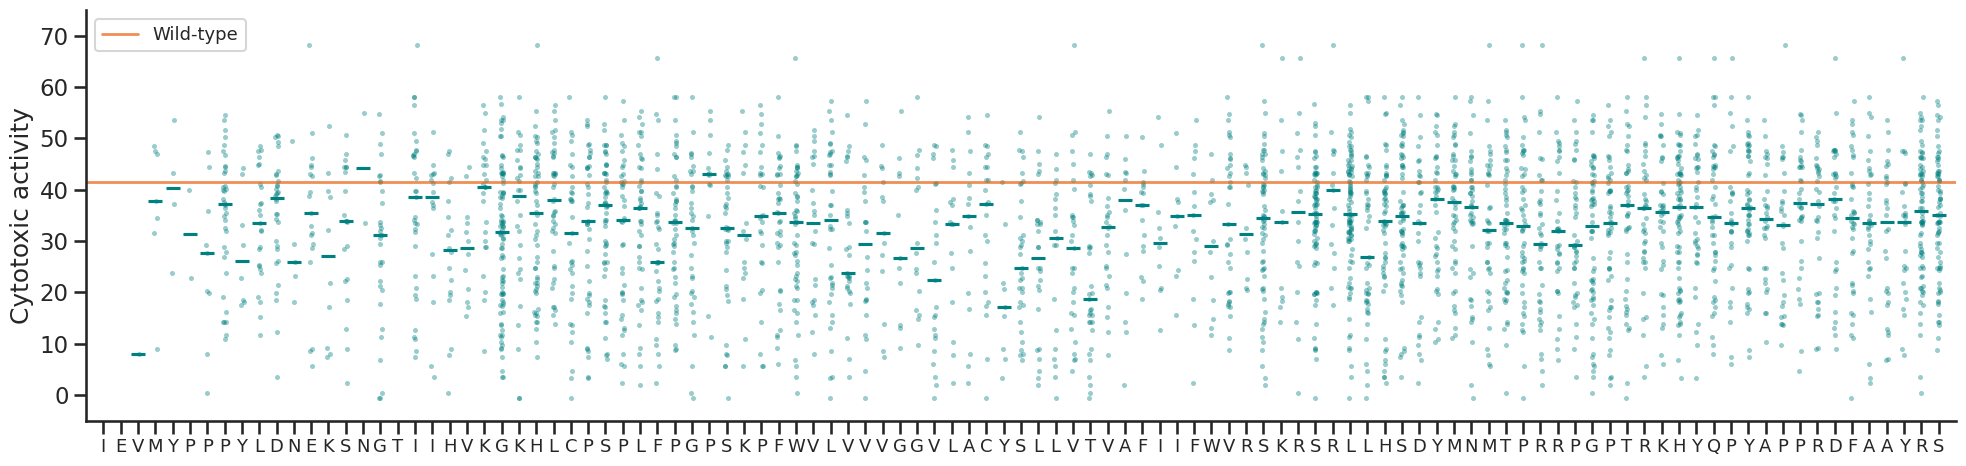

In [4]:
# Cytotoxicity
d = defaultdict(list)
for _, row in df_mut.iterrows():
    mut_posi = row["mutation_position"]
    cytotoxicity = row["cytotoxic_activity"]
    for val in mut_posi.split(":"):
        posi = int(val[1:-1])
        d[posi].append(cytotoxicity)


# Plot
cols = sns.color_palette("Oranges", 2)

fig, ax = plt.subplots(figsize=(20, 5))
for i in range(len(wt_seq)):
    vals = d.get(i)
    if vals is not None:
        offsets = np.random.uniform(-0.1, 0.1, size=len(vals))
        x = np.repeat(i, len(vals)) + offsets
        ax.scatter(i, np.median(vals), marker="_", s=100, color="teal") #cols2[1]
        ax.scatter(x, vals, s=13., alpha=0.4, color="teal", zorder=0, linewidth=0) #cols1[1]
ax.axhline(wt_val, linewidth=2., color=cols[1], alpha=0.7, label="Wild-type")
ax.set_xticks(range(i+1), list(wt_seq), fontsize=13)
ax.set_xlim(0-1, len(wt_seq))
ax.set_ylim(-5, 75)
ax.set_ylabel("Cytotoxic activity")
ax.legend(loc="upper left", fontsize=13, frameon=True)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/cytotoxicity_at_each_position.svg")